In [3]:
import pandas as pd
import numpy as np
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt 
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

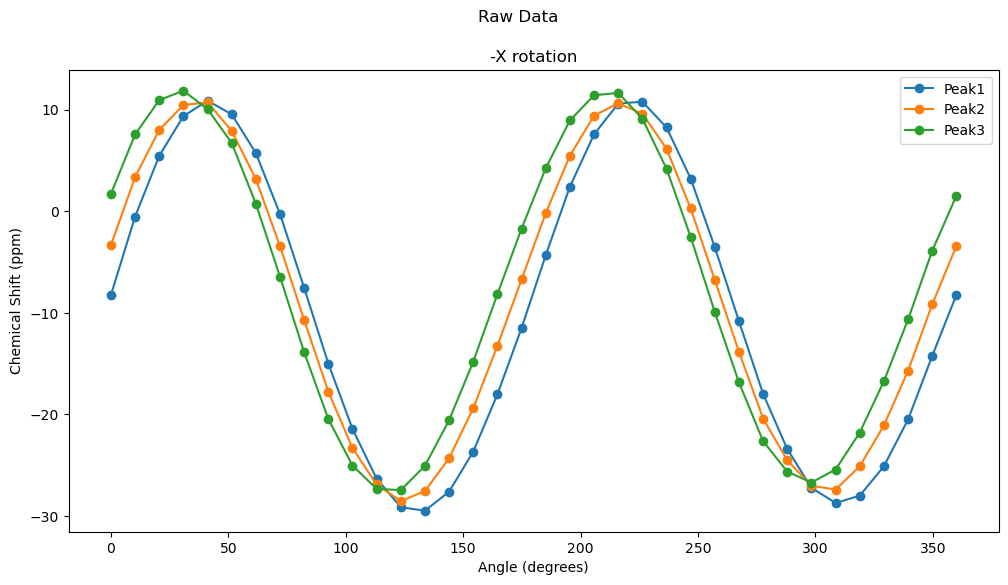

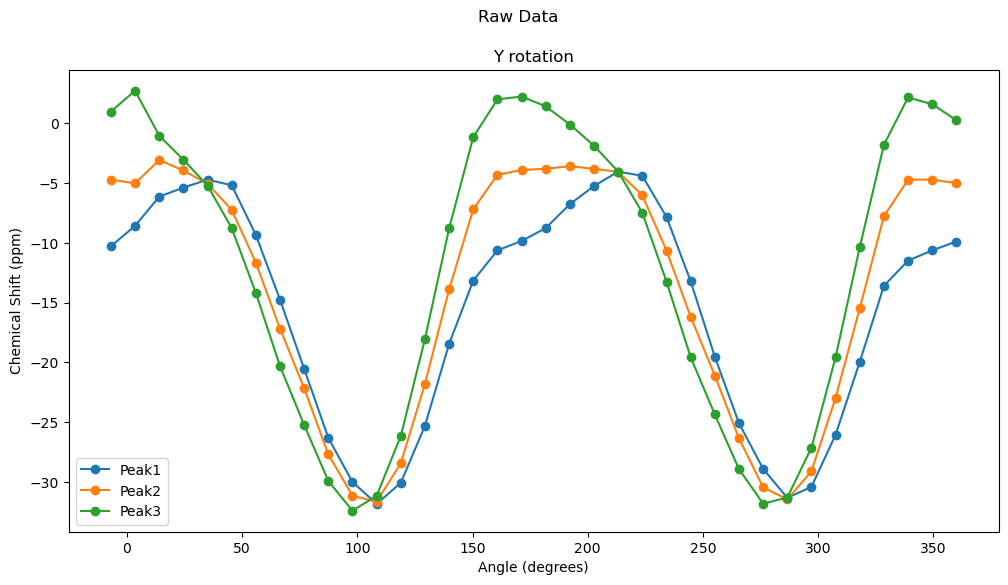

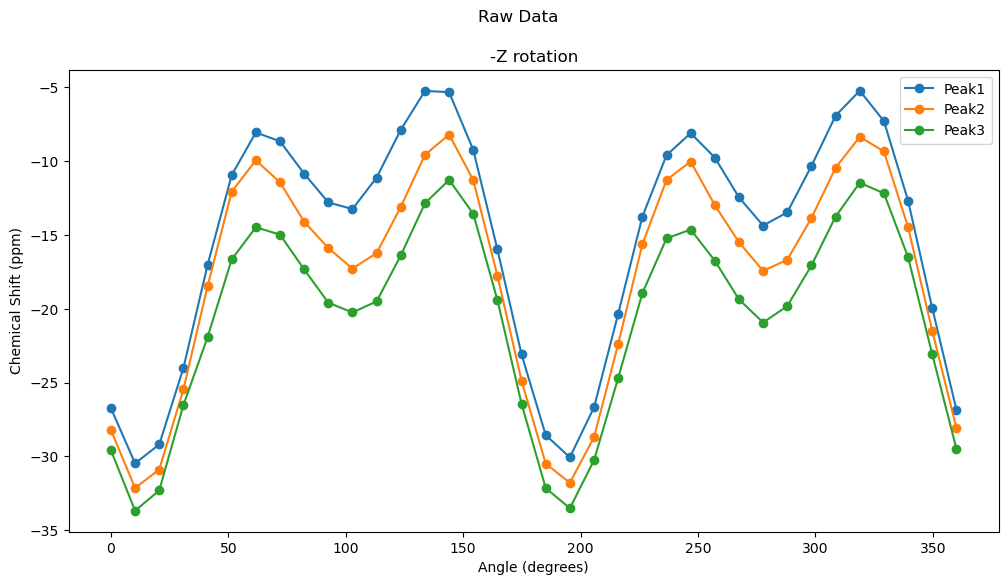

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3
w0 = 1  # Assuming w0 is defined somewhere earlier in your code

# Read data from Excel sheets
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])

for i in range(3):
    # Scale the data
    df[i]['Cluster1Peak0'] = df[i]['Cluster1Peak0'] * w0
    df[i]['Cluster1Peak1'] = df[i]['Cluster1Peak1'] * w0
    df[i]['Cluster1Peak2'] = df[i]['Cluster1Peak2'] * w0

    # Define angle and peaks
    angle = df[i]['Angle']
    peak0 = df[i]['Cluster1Peak0']
    peak1 = df[i]['Cluster1Peak1']
    peak2 = df[i]['Cluster1Peak2']

    # Create smooth curves using spline interpolation
    angle_smooth = np.linspace(angle.min(), angle.max(), 36)  # 300 points for smooth curve

    spline_peak0 = make_interp_spline(angle, peak0, k=5)(angle_smooth)
    spline_peak1 = make_interp_spline(angle, peak1, k=5)(angle_smooth)
    spline_peak2 = make_interp_spline(angle, peak2, k=5)(angle_smooth)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(angle_smooth, spline_peak0, label='Peak1', marker='o')
    plt.plot(angle_smooth, spline_peak1, label='Peak2', marker='o')
    plt.plot(angle_smooth, spline_peak2, label='Peak3', marker='o')

    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (ppm)')
    plt.title(titles[i])
    plt.legend()
    plt.show()